# Punto 2 — Regulador lineal-cuadrático: Riccati e integración numérica

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Definir los datos del problema

In [2]:
A = np.array([[0.0, 1.0],
              [0.0, 0.0]])
B = np.array([[0.0],
              [1.0]])
Q = 2 * np.eye(2)
R = np.array([[1.0]])
Rinv = np.linalg.inv(R)

T = 8.0
x0 = np.array([100.0, -20.0])

## Funciones

In [3]:
def riccati_rhs(P, A, B, Q, Rinv):
    """Lado derecho de la ecuación de Riccati A^T P + P A - P B R^-1 B^T P + 2Q"""
    BRBt = B @ Rinv @ B.T
    return A.T @ P + P @ A - P @ BRBt @ P + 2 * Q

def riccati_rhs_flat(tau, P_flat, A, B, Q, Rinv):
    """Es necesario aplanar el lado derecho de la ecuación de Riccati ya que solve_ivp espera vectores y no matrices."""
    P = P_flat.reshape(2, 2)
    dP = riccati_rhs(P, A, B, Q, Rinv)
    return dP.flatten()

def integrador_propio(A, B, Q, R, T, dt):
    """Implementación del integrador propio para la ecuación de Riccati."""
    Rinv = np.linalg.inv(R)
    n_steps = int(round(T / dt))
    
    P = np.zeros((2, 2))         
    P_hist = [P.copy()]
    
    for _ in range(n_steps):
        P = P + dt * riccati_rhs(P, A, B, Q, Rinv)
        P_hist.append(P.copy())
    
    tau_grid = np.linspace(0, T, n_steps + 1)
    t_grid = T - tau_grid                     
    
    orden = np.argsort(t_grid)
    t_grid = t_grid[orden]
    P_hist = [P_hist[i] for i in orden]
    
    return t_grid, P_hist

def P_referencia(t):
    """Evalúa la solución de referencia (RK45) en el instante original t."""
    tau = T - t
    return sol_rk.sol(tau).reshape(2, 2)

def calcular_error(t_grid, P_hist, P_ref_func):
    """Calcula el error entre la solución propia y la solución de referencia en cada instante de tiempo."""
    errores = []
    for t, P in zip(t_grid, P_hist):
        diff = P - P_ref_func(t)
        errores.append(np.linalg.norm(diff, ord="fro"))
    return np.array(errores)

def dinamica_lazo_cerrado(t, x, A, B, Rinv, P_func):
    """Calculo de la dinámica del sistema en lazo cerrado usando la ley de retroalimentación."""
    P = P_func(t)
    u = -Rinv @ B.T @ P @ x     
    dx = A @ x + (B @ u).flatten()
    return dx

def u_optimo(t, x, Rinv, B, P_func):
    P = P_func(t)
    return (-Rinv @ B.T @ P @ x).item()

### 1.1. Implementar un integrador propio para la ecuación diferencial de Ricatti

In [4]:
dt = 0.01
t_grid, P_hist = integrador_propio(A, B, Q, R, T, dt)

print("P(T) =\n", P_hist[-1])   
print("\nP(0) =\n", P_hist[0])  

P(T) =
 [[0. 0.]
 [0. 0.]]

P(0) =
 [[5.65685413 1.99999992]
 [1.99999992 2.82842707]]


Para integrar la ecuación de Riccati hacia atrás con un método propio de diferencias finitas, se hace el cambio de variable τ=T-t, que convierte la 
condición de frontera P(T)=0 en una condición inicial P(τ=0)=0 y permite integrar hacia adelante en τ con Euler explícito: P_{n+1} = P_n + Δτ·g(P_n). 
Al final se revierte τ a la variable original t. 
Se verifica que P(T)=0 (condición de frontera) y que P(t) es simétrica en todo el dominio, como debe 
serlo por construcción del problema LQR.

### 1.2. Implementación de un integrador Runge-kutta

In [5]:
sol_rk = solve_ivp(
    riccati_rhs_flat, [0, T], np.zeros(4),
    args=(A, B, Q, Rinv),
    method="RK45", dense_output=True,
    rtol=1e-10, atol=1e-12
)

In [6]:
print("\nP(T) (RK45) =\n", sol_rk.sol(0).reshape(2, 2))  
print("\nP(0) (RK45) =\n", sol_rk.sol(T).reshape(2, 2))   


P(T) (RK45) =
 [[0. 0.]
 [0. 0.]]

P(0) (RK45) =
 [[5.65685409 1.9999999 ]
 [1.9999999  2.82842706]]


Se resuelve la misma ecuación de Riccati usando el integrador Runge-Kutta RK45 de la librería scipy (solve_ivp). Al evaluar en τ=0 
y τ=T se recuperan P(T)=0 (condición de frontera) y P(0), respectivamente, coincidiendo con los resultados del integrador propio.

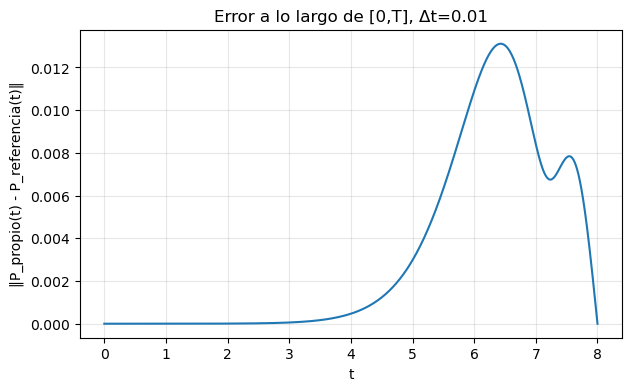

In [7]:
dt_prueba = 0.01
t_grid, P_hist = integrador_propio(A, B, Q, R, T, dt_prueba)
errores = calcular_error(t_grid, P_hist, P_referencia)

plt.figure(figsize=(7, 4))
plt.plot(t_grid, errores)
plt.xlabel("t")
plt.ylabel("‖P_propio(t) - P_referencia(t)‖")
plt.title(f"Error a lo largo de [0,T], Δt={dt_prueba}")
plt.grid(True, alpha=0.3)
plt.show()

Se compara el integrador propio (Euler explícito) contra la solución de referencia obtenida con RK45, fijando un único Δt=0.01, para observar cómo se distribuye el error a lo largo del tiempo. El error es prácticamente nulo cerca de t=T (ambos parten de P(T)=0) y crece a medida que se acumula el error de truncamiento, alcanzando su máximo en la zona donde P(t) cambia más rápido. 

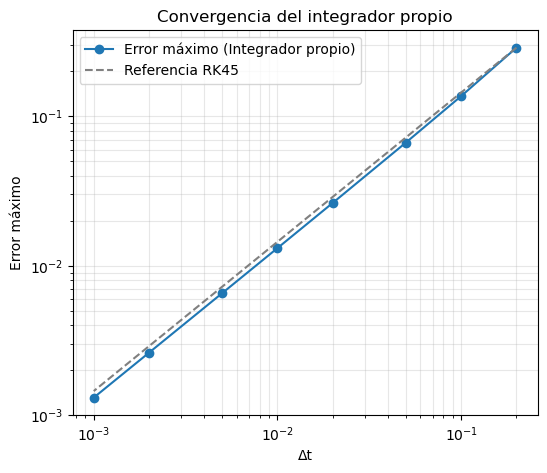

In [8]:
dt_valores = [0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
error_max = []

for dt in dt_valores:
    t_grid, P_hist = integrador_propio(A, B, Q, R, T, dt)
    errores = calcular_error(t_grid, P_hist, P_referencia)
    error_max.append(np.max(errores))

plt.figure(figsize=(6, 5))
plt.loglog(dt_valores, error_max, "o-", label="Error máximo (Integrador propio)")
plt.loglog(dt_valores, [error_max[0]*(dt/dt_valores[0]) for dt in dt_valores],
           "--", color="gray", label="Referencia RK45")
plt.xlabel("Δt")
plt.ylabel("Error máximo")
plt.title("Convergencia del integrador propio")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

A diferencia de la gráfica anterior, aquí se compara el integrador propio contra RK45 usando varios valores de Δt, para ver cómo cambia el error 
máximo al refinar el paso. Se observa que el error decae proporcionalmente a Δt, confirmando que el integrador propio es de primer orden.

### 1.3. Propagación hacia adelante usando la ley de retroalimentación

In [9]:
P_control = P_referencia 
x0 = np.array([100.0, -20.0])   # 100 m de altura, cayendo a 20 m/s

sol_x_lazo_cerrado = solve_ivp(
    dinamica_lazo_cerrado, [0, T], x0,
    args=(A, B, Rinv, P_control),
    method="RK45", dense_output=True,
    rtol=1e-8, atol=1e-10, max_step=0.05
)

t_plot = np.linspace(0, T, 300)
x_plot = sol_x_lazo_cerrado.sol(t_plot)     

u_plot = np.array([u_optimo(t, x_plot[:, i], Rinv, B, P_control) 
                    for i, t in enumerate(t_plot)])

In [10]:
print("\nx(0) =\n", sol_x_lazo_cerrado.sol(0))   
print("\nx(T) =\n", sol_x_lazo_cerrado.sol(T))    


x(0) =
 [100. -20.]

x(T) =
 [ 0.01883115 -0.02070373]


Como ya tenemos dos versiones de P(t) (la propia y la de RK45) y confirmamos que coinciden muy bien, usamos la de RK45 (P_referencia) porque nos da una función continua y muy precisa, cómoda para evaluar en cualquier instante. Los valores obtenidos son los esperados: x(0)=(100,-20), tal como se definió, y x(T) muy cerca de 
(0,0).

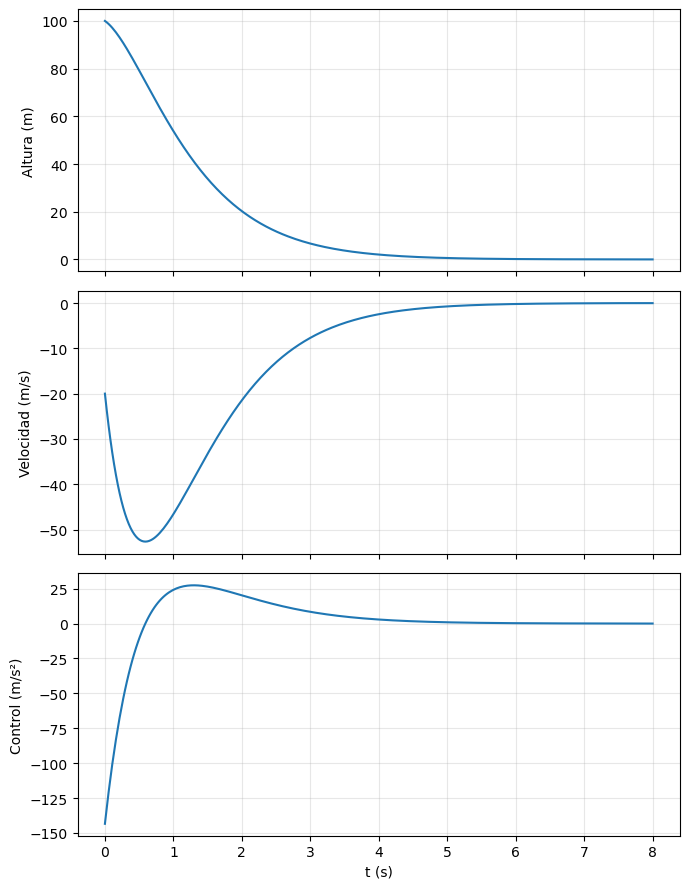

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

axes[0].plot(t_plot, x_plot[0])
axes[0].set_ylabel("Altura (m)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_plot, x_plot[1])
axes[1].set_ylabel("Velocidad (m/s)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_plot, u_plot)
axes[2].set_ylabel("Control (m/s²)")
axes[2].set_xlabel("t (s)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las tres curvas son consistentes: la altura cae monótonamente, la velocidad se hace más negativa mientras la caída se acelera y luego se acerca a cero al frenar, y el control u*(t) es negativo mientras acelera la caída y positivo cuando frena.

### 1.4. Discusión (RK45-paso adaptativo)

Un método de paso adaptativo ajusta Δt automáticamente durante la integración, usando pasos grandes donde la solución cambia lento y pasos 
pequeños donde cambia rápido. RK45 logra esto calculando en cada paso dos aproximaciones (de orden 4 y 5) con las mismas evaluaciones de la función. La diferencia entre ambas estima el error local, y según si supera o no la tolerancia pedida, el método acepta el paso y agranda Δt, o lo rechaza y lo reduce. Un método de paso fijo necesita un Δt pequeño en todo el dominio para capturar bien esa zona, mientras que RK45 concentra el esfuerzo computacional solo donde se necesita, logrando la precisión pedida con muchas menos evaluaciones.